In [2]:
import sys
sys.path.append("../")

In [3]:
import pandas as pd

train = pd.read_csv("../data/raw/train.csv", low_memory=False)
store = pd.read_csv("../data/raw/store.csv", low_memory=False)

In [4]:
train['StateHoliday'] = train['StateHoliday'].astype(str)

In [5]:
df = train.merge(store, on="Store", how="left")

print(df.shape)
df.head()

(1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
# Keep only open stores
df = df[df['Open'] == 1]

# Remove zero sales
df = df[df['Sales'] > 0]

In [8]:
df.isnull().sum().sort_values(ascending=False).head(10)

Promo2SinceWeek              423292
PromoInterval                423292
Promo2SinceYear              423292
CompetitionOpenSinceYear     268600
CompetitionOpenSinceMonth    268600
CompetitionDistance            2186
DayOfWeek                         0
Store                             0
Date                              0
Sales                             0
dtype: int64

In [9]:
## handle missing values

df['CompetitionDistance'] = df['CompetitionDistance'].fillna(
    df['CompetitionDistance'].median()
)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0)
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)

df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)
df['PromoInterval'] = df['PromoInterval'].fillna('None')

In [10]:
## extract time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

In [11]:
## Add deraived features
df['CompetitionOpenSince'] = (
    df['CompetitionOpenSinceYear'] * 12 +
    df['CompetitionOpenSinceMonth']
)

df['CompetitionDuration'] = (
    df['Year'] * 12 + df['Month']
) - df['CompetitionOpenSince']

df['Promo2Since'] = (
    df['Promo2SinceYear'] * 52 +
    df['Promo2SinceWeek']
)

df['PromoDuration'] = (
    df['Year'] * 52 + df['Week']
) - df['Promo2Since']

In [12]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)

In [13]:
import numpy as np

store_price_map = {
    'a': 900,
    'b': 700,
    'c': 500,
    'd': 300
}

df['BasePrice'] = df['StoreType'].map(store_price_map)

# Demand signal (normalized)
df['DemandFactor'] = df['Sales'] / df['Sales'].mean()

# Competition effect
df['CompetitionFactor'] = 1 / (1 + df['CompetitionDistance'] / 1000)

# Promo effect
df['PromoFactor'] = np.where(df['Promo'] == 1, 0.8, 1.0)

# 🔥 NEW: Elasticity factor (important)
df['ElasticityNoise'] = np.random.uniform(0.7, 1.3, size=len(df))

# Final price (LESS dependent on sales now)
df['Price'] = (
    df['BasePrice'] *
    df['CompetitionFactor'] *
    df['PromoFactor'] *
    df['ElasticityNoise']
)

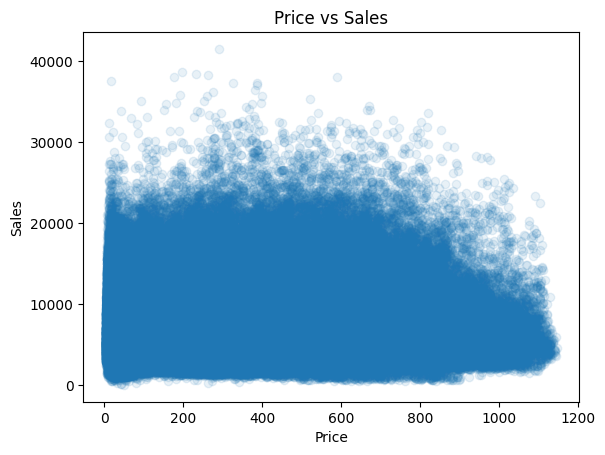

In [14]:
import matplotlib.pyplot as plt

plt.scatter(df['Price'], df['Sales'], alpha=0.1)
plt.xlabel("Price")
plt.ylabel("Sales")
plt.title("Price vs Sales")
plt.show()

In [15]:
df.to_csv("../data/processed/pricing_data.csv", index=False)

In [16]:
import pandas as pd
import numpy as np 

df = pd.read_csv("../data/processed/pricing_data.csv",low_memory=False)
df['Date'] = pd.to_datetime(df['Date'])


In [17]:
# Simple inverse demand relation (clean & stable)

df['AdjustedSales'] = df['Sales'] * (df['Price'].mean() / df['Price'])

# Add small noise
df['AdjustedSales'] = df['AdjustedSales'] * np.random.normal(1, 0.05, len(df))

# Clip
df['AdjustedSales'] = df['AdjustedSales'].clip(lower=1)

In [18]:
features = [
    'Store',
    'DayOfWeek',
    'Promo',
    'SchoolHoliday',
    'CompetitionDistance',
    'CompetitionDuration',
    'PromoDuration',
    'Month',
    'Price',
    'StoreType',
    'Assortment'
]

target = 'AdjustedSales'

In [19]:
leak_cols = [
    'Customers',
    'DemandFactor',
    'BasePrice',
    'CompetitionFactor',
    'PromoFactor',
    'ElasticityNoise',
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceYear',
    'Promo2SinceWeek',
    'Promo2SinceYear',
    'Promo2Since',
    'CompetitionOpenSince',
    'Week',
    'Day'
]

df = df.drop(columns=leak_cols, errors='ignore')

In [20]:
df = df[features + ['Date', target]]

In [21]:
# One-hot encode categorical features

df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=['StoreType', 'Assortment'], drop_first=True)



In [22]:
#time - based split after sorting data by date
df_model = df_model.sort_values('Date')

train_df = df_model[df_model['Date'] < '2015-01-01']
test_df = df_model[df_model['Date'] >= '2015-01-01']

X_train = train_df.drop(columns=[target, 'Date'])
y_train = train_df[target]

X_test = test_df.drop(columns=[target, 'Date'])
y_test = test_df[target]

In [23]:
print(X_train.columns)

Index(['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'CompetitionDistance',
       'CompetitionDuration', 'PromoDuration', 'Month', 'Price', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c'],
      dtype='object')


In [24]:
# train XGBoost model
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [25]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/xgb_model.pkl")

['../models/xgb_model.pkl']

In [26]:
from sklearn.metrics import mean_absolute_percentage_error

y_pred = model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, y_pred)
print("MAPE:", mape)

MAPE: 0.2932520727251272


In [27]:
def optimize_price(row, model, columns):
    import numpy as np
    import pandas as pd

    price_range = np.linspace(
    row['Price'] * 0.5,
    row['Price'] * 1.5,
    50
)
    
    best_price = None
    best_revenue = -np.inf
    revenues = []
    
    for price in price_range:
        temp = row.copy()
        temp['Price'] = price
        
        # ✅ FIX: keep dataframe structure
        temp_df = pd.DataFrame([temp])
        temp_df = temp_df[columns]  # ensure correct column order
        
        pred_sales = model.predict(temp_df)[0]
        revenue = price * pred_sales
        
        revenues.append((price, revenue))
        
        if revenue > best_revenue:
            best_revenue = revenue
            best_price = price
    
    return best_price, best_revenue, revenues

In [28]:
sample = X_test.iloc[0]

best_price, best_revenue, results = optimize_price(sample, model, X_train.columns)

print("Optimal Price:", best_price)
print("Expected Revenue:", best_revenue)

Optimal Price: 497.325765114505
Expected Revenue: 3110206.6127646263


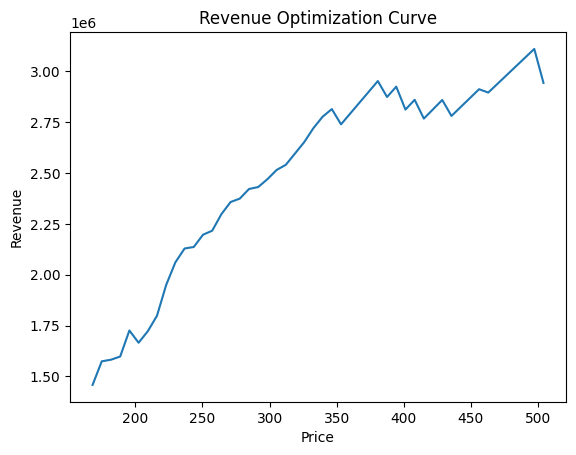

In [29]:
import matplotlib.pyplot as plt

prices = [r[0] for r in results]
revenues = [r[1] for r in results]

plt.plot(prices, revenues)
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.title("Revenue Optimization Curve")
plt.show()

#### A/B Simulation Function


In [30]:
import numpy as np
import pandas as pd

def simulate_ab_test(row, model, columns, price_a, price_b, n_sim=500):
    results = {}

    for price in [price_a, price_b]:
        simulated_revenues = []

        for _ in range(n_sim):
            temp = row.copy()
            temp['Price'] = price

            temp_df = pd.DataFrame([temp])
            temp_df = temp_df[columns]

            # Predict base demand
            pred_sales = model.predict(temp_df)[0]

            # Add randomness (Monte Carlo)
            noise = np.random.normal(1, 0.1)  # 10% variability
            simulated_sales = max(pred_sales * noise, 1)

            revenue = price * simulated_sales
            simulated_revenues.append(revenue)

        results[price] = {
            "mean": np.mean(simulated_revenues),
            "std": np.std(simulated_revenues),
            "all": simulated_revenues
        }

    return results

In [31]:
sample = X_test.iloc[0]

results = simulate_ab_test(
    sample,
    model,
    X_train.columns,
    price_a=300,
    price_b=400
)

for price, stats in results.items():
    print(f"\nPrice ₹{price}")
    print(f"Mean Revenue: {stats['mean']:.2f}")
    print(f"Risk (std): {stats['std']:.2f}")


Price ₹300
Mean Revenue: 2480312.75
Risk (std): 247363.42

Price ₹400
Mean Revenue: 2960180.75
Risk (std): 280871.38


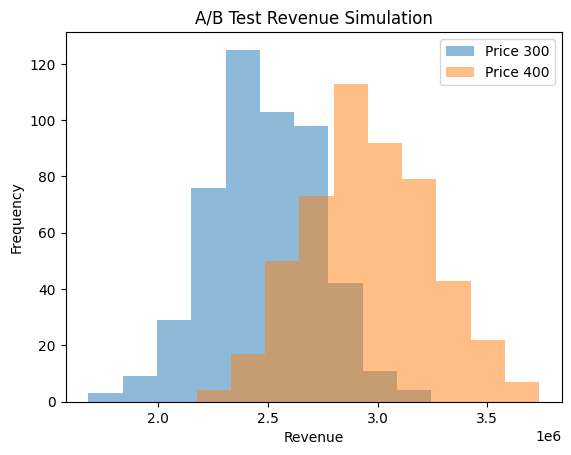

In [32]:
import matplotlib.pyplot as plt

plt.hist(results[300]['all'], alpha=0.5, label='Price 300')
plt.hist(results[400]['all'], alpha=0.5, label='Price 400')

plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.title("A/B Test Revenue Simulation")
plt.legend()
plt.show()

In [33]:
import shap
import numpy as  np

def predict_fn(data):
    return model.predict(data)

# background sample 
X_background = X_train.sample(100, random_state=42)

# create explainer
explainer = shap.KernelExplainer(predict_fn, X_background)

# Use a sample (IMPORTANT: don’t use full dataset)
X_sample = X_train.sample(50, random_state=42)

shap_values = explainer.shap_values(X_sample)

  0%|          | 0/50 [00:00<?, ?it/s]

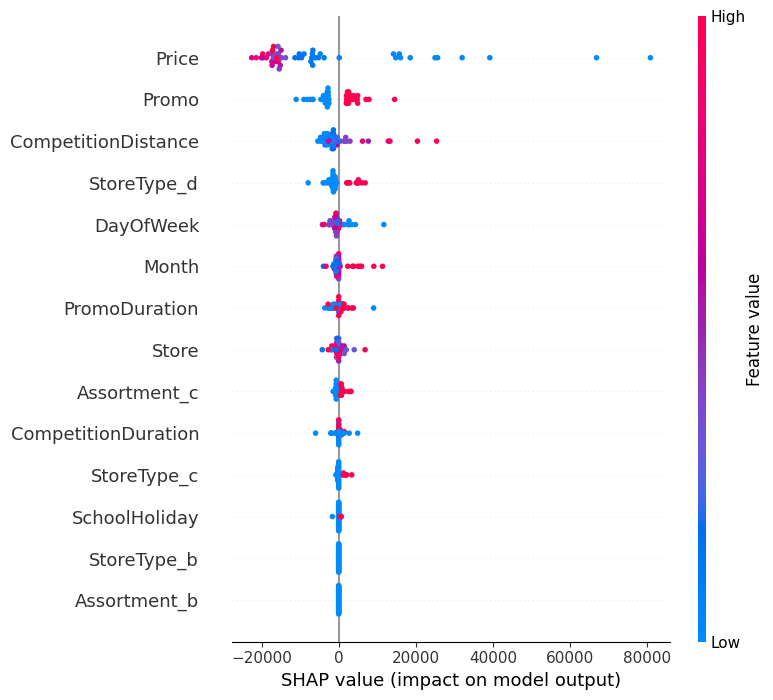

In [34]:
shap.summary_plot(shap_values, X_sample)
plt.savefig("shap_summary.png", bbox_inches='tight')
plt.close()

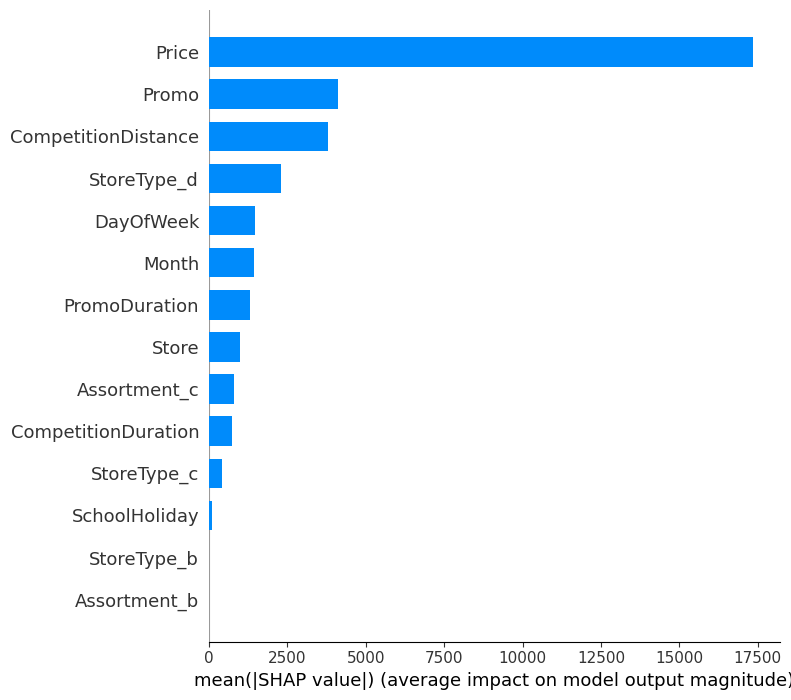

In [35]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")
plt.savefig("shap_bar.png", bbox_inches='tight')
plt.close()

In [36]:
shap.force_plot(explainer.expected_value, shap_values[0], 
                X_sample.iloc[0], matplotlib=True, show=False)
plt.savefig("shap_force.png", bbox_inches='tight')
plt.close()

In [37]:
print(X_test.columns)

Index(['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'CompetitionDistance',
       'CompetitionDuration', 'PromoDuration', 'Month', 'Price', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c'],
      dtype='object')


In [38]:
print(sample.index)

Index(['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'CompetitionDistance',
       'CompetitionDuration', 'PromoDuration', 'Month', 'Price', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c'],
      dtype='object')


In [39]:
from src.train_model import train_model

model_test = train_model(X_train, y_train)

print(type(model_test))

<class 'xgboost.sklearn.XGBRegressor'>


In [40]:
import importlib
import src.price_optimizer

importlib.reload(src.price_optimizer)

from src.price_optimizer import optimize_price

sample = X_test.iloc[0]

best_price, best_revenue = optimize_price(
    sample,
    model,
    X_train.columns
)

print(best_price, best_revenue)

381.326452290651 2957036.0061175614


In [41]:
import importlib

from src.simulation import compare_prices

importlib.reload(src.simulation)
sample = X_test.iloc[0]

results = compare_prices(
    sample,
    model,
    X_train.columns,
    prices=[300, 400]
)

for r in results:
    print(r)

{'price': 300, 'mean_revenue': 2466107.75, 'risk_std': 229176.046875}
{'price': 400, 'mean_revenue': 3003791.25, 'risk_std': 306748.9375}


In [42]:
from src.data_preprocessing import clean_input_data

test_df = df.head(5)

cleaned = clean_input_data(test_df)

print(cleaned.isnull().sum())

Store                  0
DayOfWeek              0
Promo                  0
SchoolHoliday          0
CompetitionDistance    0
CompetitionDuration    0
PromoDuration          0
Month                  0
Price                  0
StoreType              0
Assortment             0
Date                   0
AdjustedSales          0
dtype: int64


In [43]:
from src.feature_engineering import create_features

test_df = df.head(5)

features_df = create_features(test_df)

print(features_df.head())

   Store  DayOfWeek  Promo  SchoolHoliday  CompetitionDistance  \
0      1          4      1              1               1270.0   
1      2          4      1              1                570.0   
2      3          4      1              1              14130.0   
3      4          4      1              1                620.0   
4      5          4      1              1              29910.0   

   CompetitionDuration  PromoDuration  Month       Price StoreType Assortment  \
0                 82.0       104811.0      7  221.528957         c          a   
1                 92.0          278.0      7  401.452138         a          a   
2                103.0          225.0      7   55.873785         a          a   
3                 70.0       104811.0      7  222.113422         c          c   
4                  3.0       104811.0      7   23.681998         a          a   

        Date  AdjustedSales  
0 2015-07-31    6278.248419  
1 2015-07-31    3654.841835  
2 2015-07-31   34125.70284

In [ ]:
import importlib
import src.explainability as exp

importlib.reload(exp)

from src.explainability import get_shap_values

X_background = X_train.sample(100, random_state=42)
X_sample = X_train.sample(50, random_state=42)

shap_values = get_shap_values(model, X_sample, X_background)

print(type(shap_values))

TypeError: get_shap_values() takes 2 positional arguments but 3 were given

In [ ]:
sample = X_test.iloc[0]

# Optimizer
best_price, best_revenue = optimize_price(
    sample, model, X_train.columns
)

# Simulation
comparison = compare_prices(
    sample, model, X_train.columns, prices=[300, 400]
)

print("Best Price:", best_price)
print("Best Revenue:", best_revenue)
print("Comparison:", comparison)

Best Price: 395.30660596085056
Best Revenue: 3159290.0087975105
Comparison: [{'price': 300, 'mean_revenue': 2806915.5, 'risk_std': 273138.03125}, {'price': 400, 'mean_revenue': 3194804.5, 'risk_std': 308208.03125}]
